<a href="https://colab.research.google.com/github/jyothikak05/Telugu-Image-Text-extraction-and-English-Transliterstion/blob/main/imgtotxt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing EasyOCR Image to Text Extraction Model

In [3]:
!pip install easyocr

DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


Importing libraries

In [4]:
import easyocr
import cv2
import matplotlib.pyplot as plt

Uploading File

In [1]:
from google.colab import files
uploaded = files.upload()

Saving teimg1.jpg to teimg1.jpg


PreProcessing Image

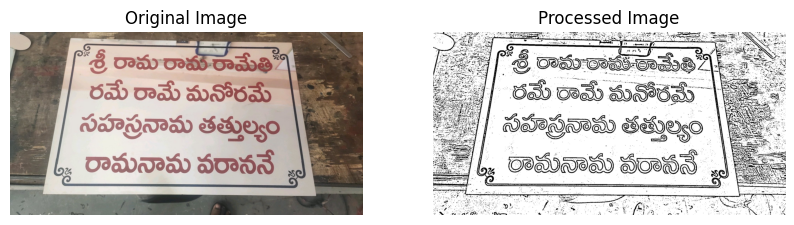

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('teimg1.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

thresh = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

cv2.imwrite('processed_teimg1.jpg', thresh)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Processed Image")
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.show()

Extracting Text From Img

In [15]:

reader = easyocr.Reader(['en'])


results = reader.readtext('teimg1.jpg')

for (bbox, text, prob) in results:
    print(f'Detected text: {text} (Probability: {prob:.4f})')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected text: 8 oomu Oea O838 (Probability: 0.0498)
Detected text: 638 Ooaf 605863 (Probability: 0.1027)
Detected text: Qafa@womu @ees0 (Probability: 0.0607)
Detected text: O3J23) @0a3a' (Probability: 0.0289)


Transliteration

In [7]:
pip install easyocr indic-transliteration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 3.6 MB/s eta 0:00:00
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [14]:
import easyocr
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate


reader = easyocr.Reader(['en', 'te'])


results = reader.readtext('teimg1.jpg')

print(f"{'Detected (Telugu)':<25} | {'Transliteration (English)':<25} | {'Conf'}")
print("-" * 70)

for (bbox, text, prob) in results:

    transliterated = transliterate(text, sanscript.TELUGU, sanscript.ITRANS)


    print(f"{text:<25} | {transliterated.lower():<25} | {prob:.2f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected (Telugu)         | Transliteration (English) | Conf
----------------------------------------------------------------------
శ్రీ రామ రామ రామేతి       | shri rama rama rameti     | 0.57
రమే రామే మనోరమే           | rame rame manorame        | 0.74
సహస్రనామ తత్తుల్యం        | sahasranama tattulyam     | 0.49
రామనామ వరాననే             | ramanama varanane         | 0.67
